### ___

<img src='ulster_logo.png' /></a>
___
# Logistic Regression Project 

In this project we will be working with a fake advertising data set, indicating whether or not a particular internet user clicked on an Advertisement. We will try to create a model that will predict whether or not they will click on an ad based off the features of that user.

This data set contains the following features:

* 'Daily Time Spent on Site': consumer time on site in minutes
* 'Age': cutomer age in years
* 'Area Income': Avg. Income of geographical area of consumer
* 'Daily Internet Usage': Avg. minutes a day consumer is on the internet
* 'Ad Topic Line': Headline of the advertisement
* 'City': City of consumer
* 'Male': Whether or not consumer was male
* 'Country': Country of consumer
* 'Timestamp': Time at which consumer clicked on Ad or closed window
* 'Clicked on Ad': 0 or 1 indicated clicking on Ad

## Import Libraries

**Import a few libraries you think you'll need (Or just import them as you go along!)**

In [40]:
# For the first step i willl be importing necessary libraries required 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

## Get the Data
**Read in the advertising.csv file and set it to a data frame called ad_data.**

In [2]:
# Then i will load the dataset in a csv format to read the file
data = pd.read_csv('advertising.csv')

**Check the head of ad_data**

In [3]:
#  Then iwill input the .head funtion to check the first few rows to understand the data
data.head()


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


** Use info and describe() on ad_data**

In [4]:
# Next i will input the .info function to get information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [5]:
# This function will help me to get a concise summary of numerical columns
data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


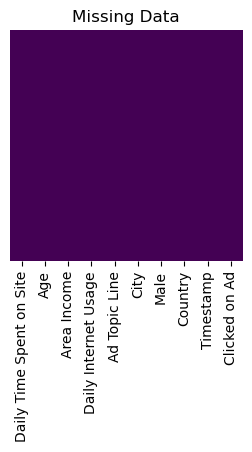

In [6]:
# Then i will create a heatmap to check if i have any missing data
plt.figure(figsize=(3, 3)) 
sns.heatmap(data.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Missing Data')
plt.show()
# As the heatmap shows there is no missing data  available 

## Exploratory Data Analysis

Let's use seaborn to explore the data!

Try recreating the plots shown below!

** Create a histogram of the Age**

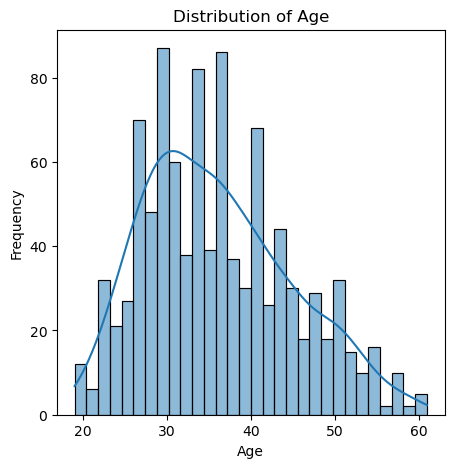

In [7]:
# Creating a histogram of Age using Seaborn 
plt.figure(figsize=(5,5))  
sns.histplot(data['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
# the below histogram shows the age group of customers in years. Most of their age lies betweeen 25-35 years old.

**Create a jointplot showing Area Income versus Age.**

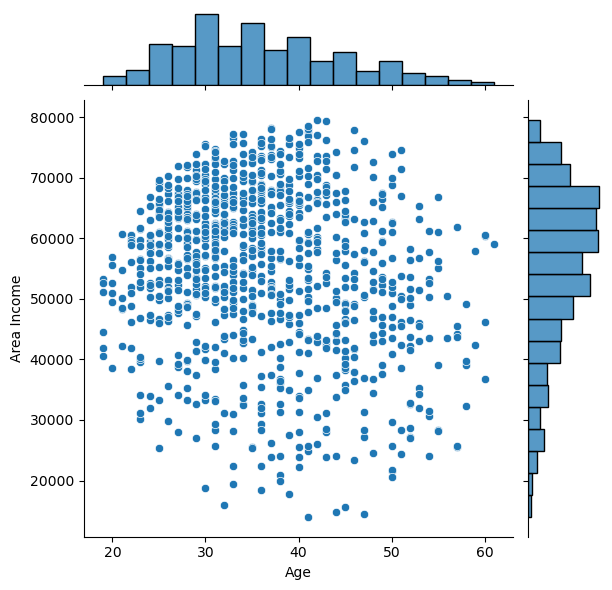

In [8]:
#Creating a jointplot displaying area income versus age
sns.jointplot(x='Age', y='Area Income', data=data, kind='scatter', height=6)
plt.xlabel('Age')
plt.ylabel('Area Income')
plt.show()
# the below jointplot displays the area income vs age. if we observe the scatterplot there 
# is a psoitive relation between the columns. 

**Create a jointplot showing the kde distributions of Daily Time spent on site vs. Age.**

<Figure size 500x500 with 0 Axes>

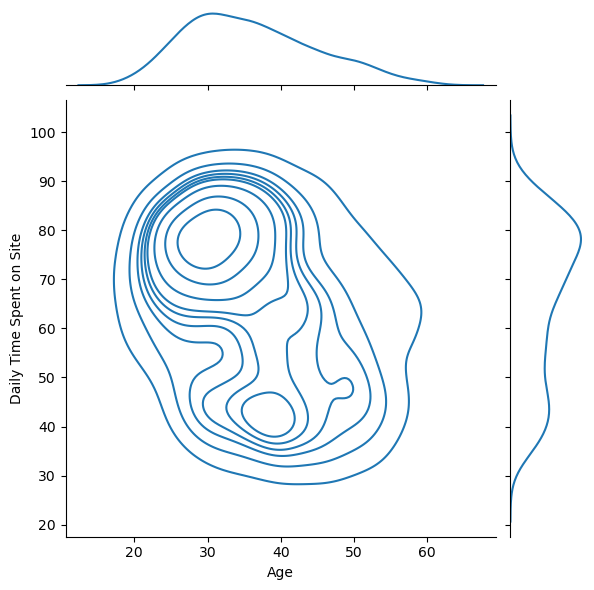

In [9]:
# Creating a jointplot displaying Daily Time Spent on Site versus Age using KDE
plt.figure(figsize=(5,5))
sns.jointplot(x='Age', y='Daily Time Spent on Site', data=data, kind="kde")
plt.xlabel('Age')
plt.ylabel('Daily Time Spent on Site')
plt.show()
#Kernel density estimation (KDE) will help to estimate the probability density of the data. 
# displays a bivariate density curve on the main plot and univariate density curves on the margins

** Create a jointplot of 'Daily Time Spent on Site' vs. 'Daily Internet Usage'**

<Figure size 500x500 with 0 Axes>

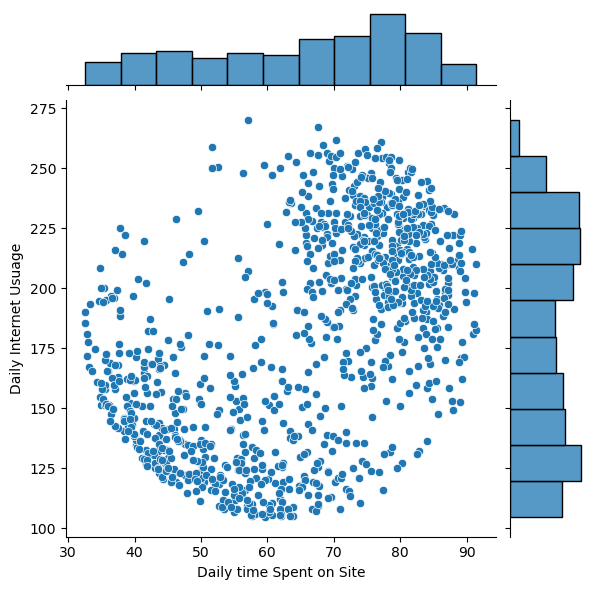

In [10]:
plt.figure(figsize=(5,5))
sns.jointplot(x='Daily Time Spent on Site', y= 'Daily Internet Usage', data=data)
plt.xlabel('Daily time Spent on Site')
plt.ylabel('Daily Internet Usuage')
plt.show()

** Finally, create a pairplot with the hue defined by the 'Clicked on Ad' column feature.**

C:\Users\adhil\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


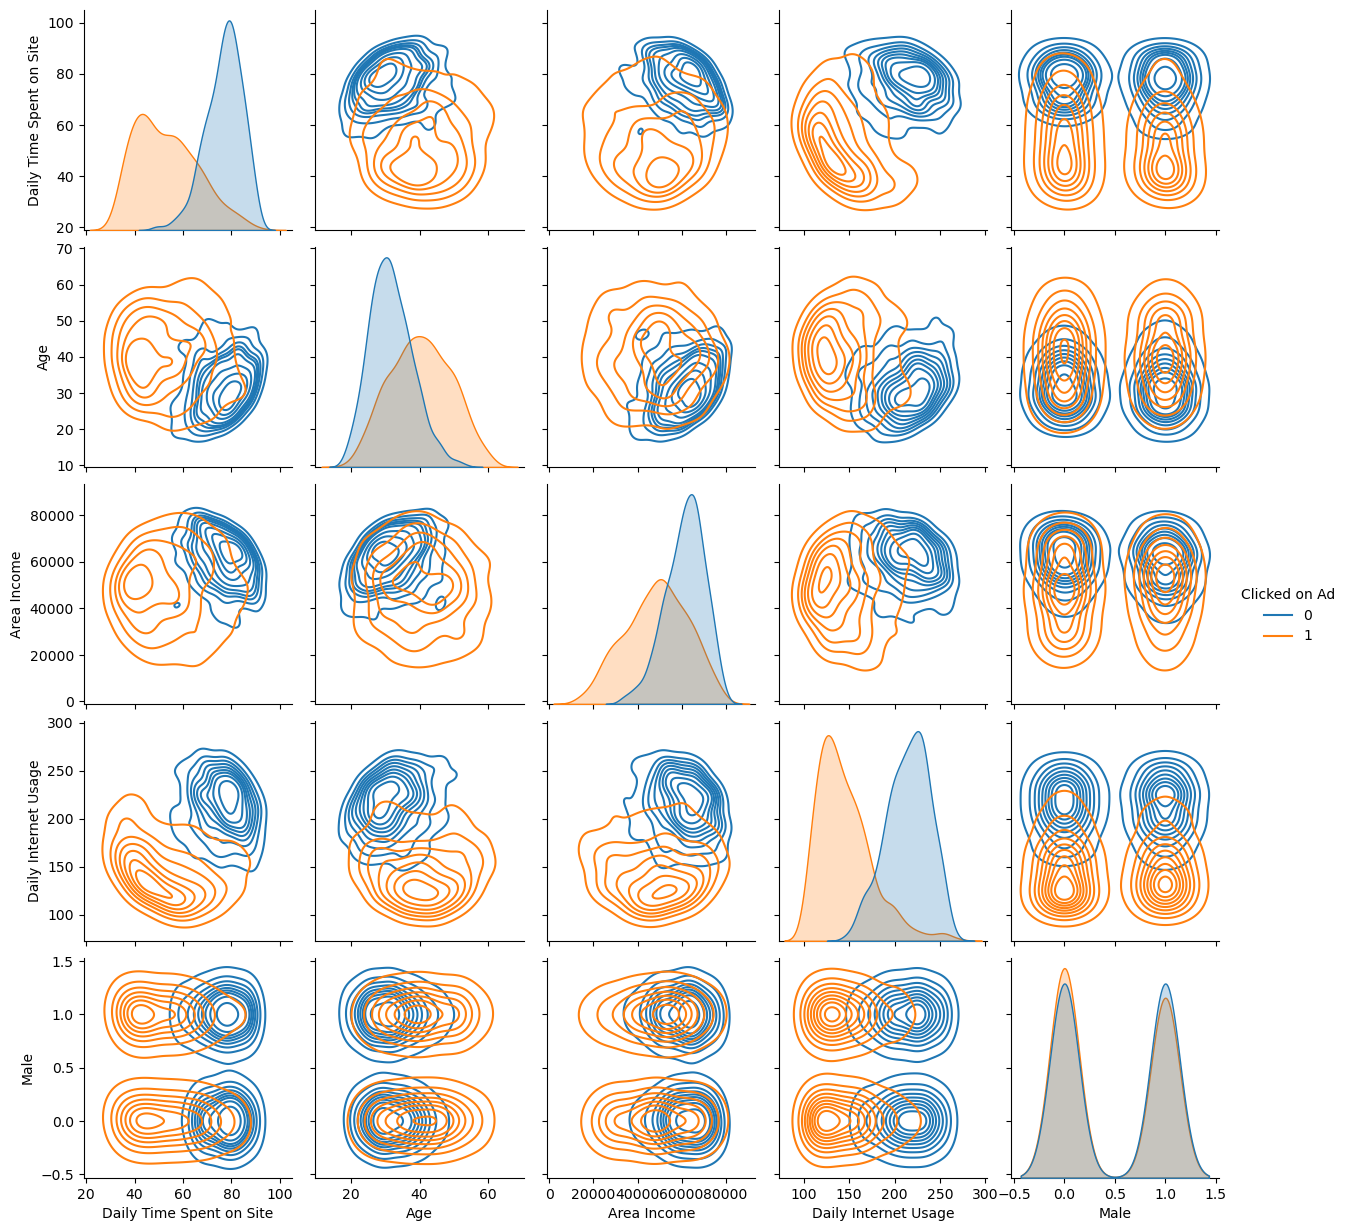

In [11]:
# Creating a pairplot with hue defined by 'Clicked on Ad'
sns.pairplot(data=data, hue='Clicked on Ad', kind ='kde', height = 2.5)
plt.show()

# Logistic Regression

Now it's time to do a train test split, and train our model!

You'll have the freedom here to choose columns that you want to train on!

** Split the data into training set and testing set using train_test_split**

In [42]:
# 'Clicked on Ad' is the target variable
# Selecting columns as features
features = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']

# X contains the selected features, y contains the target variable
X = data[features]
y = data['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# For this step i have used 80% of data for training and 20% for test. 

#Feature Engineering
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

** Train and fit a logistic regression model on the training set.**

In [43]:
from sklearn.linear_model import LogisticRegression

# Creating an instance of the Logistic Regression model
logistic_model = LogisticRegression()

# Training the model on the training data
logistic_model.fit(X_train, y_train)


LogisticRegression()

## Predictions and Evaluations
** Now predict values for the testing data.**

In [44]:
# Predicting the values for the testing data
predictions = logistic_model.predict(X_test)

** Create a classification report for the model.**

In [45]:
# For the last step i will be generating the classification report 
report = classification_report(y_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.84      0.96      0.89        89
           1       0.96      0.86      0.90       111

    accuracy                           0.90       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.91      0.90      0.90       200



In [16]:
#Four ways to check if predictions are right 
#'TN / True Negative: the case was negative and predicted negative
# TP / True Positive: the case was positive and predicted positive
# FN / False Negative: the case was positive but predicted negative
# FP / False Positive: the case was negative but predicted positive
# precision is the acuracy of positive predictions
# the formula for precision = TP/(TP + FP)
#recall is the ability of a classifier to find all positive instances
#the formula for recall = TP/(TP+FN)
# F1 score is the percentage of the positive predictions which were correct
# the formula for F1 score =2*(Recall * Precision) / (Recall + Precision)
# support is the number of actual occurrences

## Great Job!

# Random forest Model

In [17]:
#Importing random forest classifier 
from sklearn.ensemble import RandomForestClassifier

In [18]:
# the dataset has already been loaded above for linear regression model so i will not be loading it again
# the data head is also shown above 

## Defining the  feautures and target variable 

In [19]:
selected_features = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']
X = data[selected_features]
y = data['Clicked on Ad']

## Splitting the data into training and testing sets


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

#  Creating the Random Forest Classifier


In [21]:
clf = RandomForestClassifier(n_estimators=105, random_state=42)

# Training the model


In [22]:
clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=105, random_state=42)

# Predicting on the test set


In [23]:
y_pred = clf.predict(X_test)

 # Evaluating the model


In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.93


 # Other evaluation metrics


In [25]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        89
           1       0.94      0.93      0.94       111

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



In [26]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[ 83   6]
 [  8 103]]


## Support Vector Mchine Model

In [27]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

In [28]:
#The dataset has already been loaded before for the linear regression model. 
# The first few rows of the data set are also printed before

## Defining the  feautures and target variable 

In [29]:
selected_features = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']
X = data[selected_features]
y = data['Clicked on Ad']

 # Encoding categorical variables

In [30]:
 label_encoder = LabelEncoder()
X['Male'] = label_encoder.fit_transform(X['Male'])
# encoding categorial variables is necessary so that my model is able to undersatnd the algorrithm more qucikly
#Encoding also helps to prevent bias in the model by ensuring that all features are equally weighted.

C:\Users\adhil\AppData\Local\Temp\ipykernel_7220\1886386986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Male'] = label_encoder.fit_transform(X['Male'])


## Splitting the data into training and testing sets


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
# for this model also i have kept the test size to 20% and the train size will be 80%

 # Creating the Support Vector Machine Classifier


In [32]:
clf = SVC(kernel='linear')

 # Training the model


In [33]:
clf.fit(X_train, y_train)

SVC(kernel='linear')

# Predicting on the test set

In [34]:
 y_pred = clf.predict(X_test)

# Evaluating the model

In [35]:
 accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.935


 # Other evaluation metrics

In [36]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        89
           1       0.96      0.92      0.94       111

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200



In [37]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[ 85   4]
 [  9 102]]


# CONCLUSION

In [ ]:
#From the above tested models, the model which gave the best accuracy is the SVM model.
#Random forest model and Support vector machine model have the save f1 score.
#The execution of the model is also based on features and the target variable, changes could be made by switching them. 
#the F1 score of all the models is aslso close 1 whcich is also statisfactory that the model is upto the mark.

# Refrences

In [3]:
# “Sklearn.svm.SVR — Scikit-Learn 0.23.1 Documentation.” Scikit-Learn.org, scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html. Accessed 6 Dec. 2023.
#R, S.E. (2023) Understand random forest algorithms with examples (updated 2023), Analytics Vidhya. Available at: https://www.analyticsvidhya.com/blog/2021/06/understanding-random-forest/ (Accessed: 05 December 2023). 
# “Sklearn.metrics.f1_score — Scikit-Learn 0.21.2 Documentation.” Scikit-Learn.org, 2019, scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html. Accessed 6 Dec. 2023.